## Credit Risk Modelling & Scoring (Kenya Fintech Simulation)

# 1. Introduction

## Problem Statement

In Kenya’s fintech ecosystem (e.g., mobile lending platforms), lenders must assess borrower risk quickly using limited but high-frequency data such as income, loan size, and mobile money activity.

### The goal of this project is to:

- Predict the likelihood of loan default  
- Convert predictions into a credit score (300–850)  
- Simulate how fintech lenders make approval decisions

## 2. Import Libraries

In [2]:
!pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\user\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Generate Synthetic Dataset

### 📌 Context

We simulate borrower data reflecting:

- Income variability  
- Mobile money usage (M-Pesa proxy)  
- Loan behavior  

This synthetic dataset helps mimic real-world fintech lending scenarios in Kenya, where high-frequency transactional data is used to assess credit risk.

### 🎯 Objective

Create a dataset that includes:

- Monthly income
- Loan amount
- Mobile money transaction volume
- Repayment behavior (default or not)

In [4]:
np.random.seed(42)

n = 1000

data = pd.DataFrame({
    "age": np.random.randint(20, 60, n),
    "monthly_income": np.random.randint(15000, 150000, n),
    "loan_amount": np.random.randint(2000, 50000, n),
    "mobile_money_txn": np.random.randint(10, 200, n),
    "loan_history": np.random.randint(0, 10, n)
})

# Risk logic
data["risk_score"] = (
    (data["loan_amount"] / data["monthly_income"]) * 0.5 +
    (1 / (data["loan_history"] + 1)) * 0.3 +
    (1 / (data["mobile_money_txn"] + 1)) * 0.2
)

# Target variable
data["default"] = (data["risk_score"] > data["risk_score"].median()).astype(int)

data.head()

,age,monthly_income,loan_amount,mobile_money_txn,loan_history,risk_score,default
0,58,149869,41071,125,9,0.168610,0
1,48,49560,49454,182,8,0.533357,1
2,34,91589,5983,90,3,0.109860,0
3,27,37116,11503,90,5,0.207158,0
4,40,147717,31921,122,6,0.152531,0


In [6]:
data.describe()

,age,monthly_income,loan_amount,mobile_money_txn,loan_history,risk_score,default
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,39.991000,83246.294000,24614.233000,104.679000,4.612000,0.297152,0.50000
std,11.780055,38915.882839,13734.721329,54.550726,2.871184,0.229517,0.50025
min,20.000000,15163.000000,2097.000000,10.000000,0.000000,0.043744,0.00000
25%,30.000000,49065.000000,12713.250000,59.000000,2.000000,0.146279,0.00000
50%,41.000000,82923.000000,23808.500000,105.000000,5.000000,0.230420,0.50000
75%,50.250000,116474.250000,36087.250000,152.000000,7.000000,0.372808,1.00000
max,59.000000,149869.000000,49968.000000,199.000000,9.000000,1.710917,1.00000


## 4. Exploratory Data Analysis (EDA)

### Dataset Overview

Before building any predictive model, we explore the dataset to understand:

- Data structure and feature types  
- Distribution of variables  
- Presence of outliers or anomalies  
- Relationships between features  
- Class balance (default vs non-default)  

This step helps identify patterns and guides feature engineering and model selection.

### Class Distribution

In [7]:
data["default"].value_counts(normalize=True)

default
0    0.5
1    0.5
Name: proportion, dtype: float64

- Insight: Check if dataset is balanced or skewed

### Feature Distributions

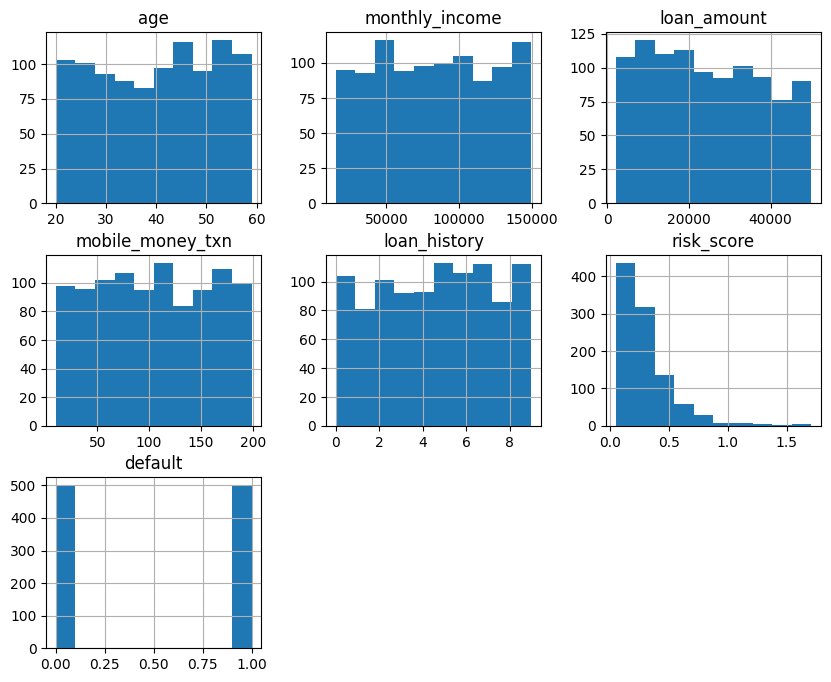

In [8]:
data.hist(figsize=(10,8))
plt.show()

### Observations:

-Income varies widely (realistic for Kenya)  
-Loan amounts are smaller relative to income

## 5. Relationship Analysis

###  Correlation Matrix

A correlation matrix helps us understand the strength and direction of relationships between variables.

- Values range from **-1 to +1**
  - **+1** → strong positive relationship  
  - **-1** → strong negative relationship  
  - **0** → no relationship  

This analysis helps identify:
- Key drivers of loan default  
- Redundant features (highly correlated variables)  
- Potential multicollinearity issues in modeling  

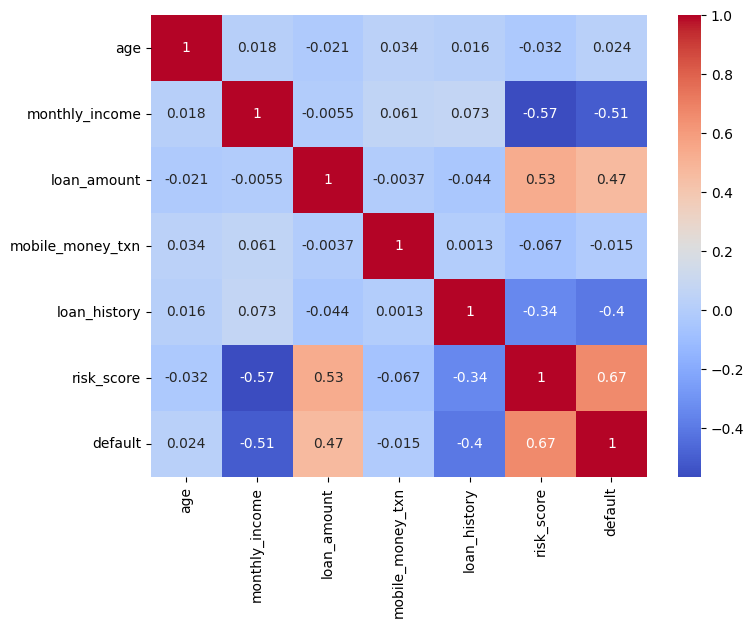

In [9]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.show()

###  Key Insights

- **Higher loan-to-income ratio → higher default risk**  
  Borrowers taking loans that are large relative to their income are more financially stretched and therefore more likely to default.

- **Higher mobile money transactions → lower risk**  
  Increased transaction activity indicates stronger financial engagement and cash flow stability, reducing default likelihood.

- **More loan history → lower risk (experienced borrowers)**  
  Borrowers with prior lending experience tend to have better repayment behavior and are considered more reliable.

## 6. Feature Preparation

In [10]:
X = data.drop(columns=["default", "risk_score"])
y = data["default"]

## 7. Train-Test Split

In [12]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.1 MB 484.7 kB/s eta 0:00:16
   -- ------------------------------------- 0.5/8.1 MB 484.7 kB/s eta 0:00:16
   --- ------------------------------------ 0.8/8.1 MB 517.9 kB/s eta 0:00:15
   --- ------------------------------------ 0.8/8.1 MB 517.9 kB/s eta 0:00:15
   ----- ---------------------------------- 1.0/8.1 MB 541.8 kB/s eta 0:00:14
   ----- ---------------------------------- 1.0/8.1 MB 541.8 kB/s eta 0:00:14
   ------ --------------------------------- 1.3/8.1 MB 567.2 kB/s eta 0:00:12
   ------ ------------------------------


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\user\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## 8. Model Building (Decision Tree)

### Why Decision Tree?
-Easy to interpret  
-Works well with non-linear relationships  
-Common in credit scoring systems  

In [14]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=5, random_state=42)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

## 9. Model Evaluation

In [15]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.90      0.93      0.91        98
           1       0.93      0.90      0.92       102

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.91       200
weighted avg       0.92      0.92      0.92       200

ROC AUC: 0.9371748699479793


### Model Evaluation Metrics

- **Precision** → Accuracy of positive predictions  
- **Recall** → Ability to detect defaulters  
- **ROC-AUC** → Overall model performance

### 10. Credit Scoring System

We convert predicted probability into a credit score:

$$
\text{Credit Score} = 300 + (1 - p) \times 550
$$

In [22]:
data["credit_score"] = (300 + (1 - model.predict_proba(X)[:,1]) * 550).astype(int)

### Interpretation

- **300** → High risk  
- **850** → Low risk

**Interpretation:** A score closer to **300** indicates high risk, while a score closer to **850** indicates low risk.

## 11. Feature Importance

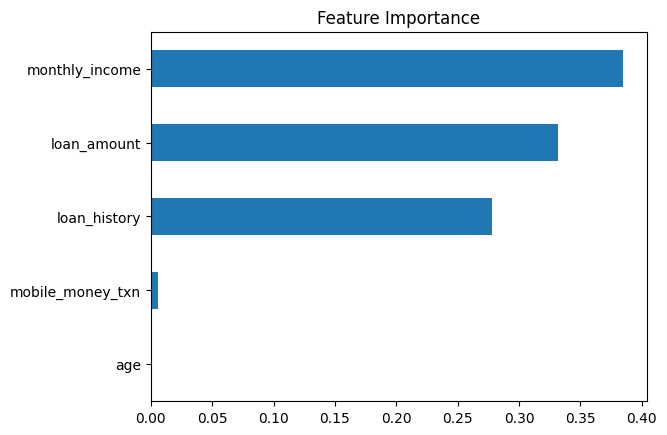

In [23]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

### Insight

- Loan amount vs income is usually the strongest predictor  
- Behavioral data (transactions, history) adds predictive power

### Insight

- **Loan amount-to-income ratio** is typically the strongest predictor of default risk  
- **Behavioral data** (e.g., transactions, repayment history) significantly improves model performance

## 12. Model Deployment (Gradio)

In [25]:
!pip install gradio

  Using cached gradio-6.13.0-py3-none-any.whl.metadata (17 kB)
  Using cached audioop_lts-0.2.2-cp313-abi3-win_amd64.whl.metadata (2.0 kB)
  Using cached fastapi-0.136.1-py3-none-any.whl.metadata (28 kB)
  Using cached gradio_client-2.5.0-py3-none-any.whl.metadata (7.1 kB)
  Using cached groovy-0.1.2-py3-none-any.whl.metadata (6.1 kB)
  Using cached hf_gradio-0.4.1-py3-none-any.whl.metadata (428 bytes)
  Using cached huggingface_hub-1.12.0-py3-none-any.whl.metadata (14 kB)
  Using cached pydub-0.25.1-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached python_multipart-0.0.26-py3-none-any.whl.metadata (2.1 kB)
  Using cached safehttpx-0.1.7-py3-none-any.whl.metadata (4.2 kB)
  Using cached semantic_version-2.10.0-py2.py3-none-any.whl.metadata (9.7 kB)
  Using cached starlette-1.0.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached uvicorn-0.46.0-py3-none-any.whl.metadata (6.7 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached hf_xet-1.4.3-cp37-abi


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\user\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [26]:
import gradio as gr

def predict_credit(age, income, loan, txn, history):
    input_data = np.array([[age, income, loan, txn, history]])
    prob = model.predict_proba(input_data)[0][1]
    score = int(300 + (1 - prob) * 550)
    
    return f"Default Risk: {round(prob,2)}, Credit Score: {score}"

interface = gr.Interface(
    fn=predict_credit,
    inputs=["number","number","number","number","number"],
    outputs="text",
    title="Credit Risk Scoring (Kenya Fintech Simulation)"
)

interface.launch()

C:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


C:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Created dataset file at: .gradio\flagged\dataset1.csv


### 13. Business Insights

####  Key Findings

- **High loan-to-income ratio** → Significantly increases default risk  
- **Low mobile money activity** → Associated with higher risk  
- **Repeat borrowers** → Tend to be more reliable

### Business Application

- **Automated approvals** → Approve loans above a defined score threshold (e.g., 600)  
- **Risk monitoring** → Flag high-risk borrowers for manual review  
- **Dynamic credit limits** → Adjust loan amounts based on predicted risk  

---



### 14. Conclusion

This project shows how machine learning can:

- Quantify and assess **credit risk**  
- Enhance **data-driven lending decisions**  
- Convert model outputs into **practical credit scoring systems**